# Peut-on prédire la graphie d'une lettre selon sa prononciation phonétique ?

**Author :** Miyu Goto

**Date :** May 2026

Des expériences très connues, comme celle de "bouba" et "kiki", ont permis d'avancer l'idée qu'il existe des associations robustes entre le son et la forme. Or, si ces associations existe pour des formes, pourquoi n'existeraient-elle pas pour l'écriture ?
Trouver une relation entre la prononciation phonétique et l'écriture des lettres c'est donc questionner plus largement l'iconicité des alphabets et le symbolisme sonore de l'écriture.


⚠️ Ce notebook doit être lancé avec un kernel Python 3.12.0 ou une version antérieure. Peut-on retrouver une logique dans 

## 1. Library Import 

In [10]:
import panphon
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
import requests, zipfile, io, os
from tqdm import tqdm
ft = panphon.FeatureTable()


In [11]:
#Télécharger la police Noto
os.makedirs("fonts", exist_ok=True)
FONT_URL = "https://github.com/googlefonts/noto-fonts/raw/main/hinted/ttf/NotoSans/NotoSans-Regular.ttf"

if not os.path.exists("fonts/NotoSans-Regular.ttf"):
    r = requests.get(FONT_URL)
    with open("fonts/NotoSans-Regular.ttf", "wb") as f:
        f.write(r.content)
    print("✅ Police Noto téléchargée")
else:
    print("✅ Police Noto déjà présente")

✅ Police Noto déjà présente


## 2. Data import

In [12]:
df = pd.read_csv('database.csv')
df

,script,grapheme,IPA,comment,source,omniglot
0,Abaza,а,a,NaN,Hewitt 2004: 260-263.,https://www.omniglot.com/writing/abaza.htm
1,Abaza,б,b,NaN,Hewitt 2004: 260-263.,https://www.omniglot.com/writing/abaza.htm
2,Abaza,в,v,NaN,Hewitt 2004: 260-263.,https://www.omniglot.com/writing/abaza.htm
3,Abaza,г,ɡ,NaN,Hewitt 2004: 260-263.,https://www.omniglot.com/writing/abaza.htm
4,Abaza,гв,ɡʷ,NaN,Hewitt 2004: 260-263.,https://www.omniglot.com/writing/abaza.htm
...,...,...,...,...,...,...
18716,Zulu 2,y,j,NaN,Doke&Vilakazi 1972: 13-903,https://omniglot.com/writing/zulu.htm
18717,Zulu 2,y,jʱ,NaN,Doke&Vilakazi 1972: 13-903,https://omniglot.com/writing/zulu.htm
18718,Zulu 2,Z,z,NaN,Doke&Vilakazi 1972: 13-903,https://omniglot.com/writing/zulu.htm
18719,Zulu 2,z,z,NaN,Doke&Vilakazi 1972: 13-903,https://omniglot.com/writing/zulu.htm


## 3. Pré-traitement

In [ ]:
# Supprimer les NA
df = df.dropna(subset=['IPA'])
df = df.dropna(subset=['grapheme'])

print(f"Lignes après suppression des NA : {len(df)}")

# Vérifier la segmentation panphon et garder uniquement les multi-phonèmes et mono-phonèmes reconnus
df['ipa_len'] = df['IPA'].apply(lambda x: len(ft.word_to_vector_list(str(x), numeric=True)))
df = df[df['ipa_len'] > 0]
print(f"Lignes après suppression des non-reconnus par panphon : {len(df)}")

print(f"\nMono-phonèmes  : {(df['ipa_len'] == 1).sum()}")
print(f"Multi-phonèmes : {(df['ipa_len'] > 1).sum()}")

Lignes après suppression des NA : 18548
Lignes après suppression des non-reconnus par panphon : 18307

Mono-phonèmes  : 12833
Multi-phonèmes : 5474


,script,grapheme,IPA,comment,source,omniglot,ipa_len
0,Abaza,а,a,NaN,Hewitt 2004: 260-263.,https://www.omniglot.com/writing/abaza.htm,1
1,Abaza,б,b,NaN,Hewitt 2004: 260-263.,https://www.omniglot.com/writing/abaza.htm,1
2,Abaza,в,v,NaN,Hewitt 2004: 260-263.,https://www.omniglot.com/writing/abaza.htm,1
3,Abaza,г,ɡ,NaN,Hewitt 2004: 260-263.,https://www.omniglot.com/writing/abaza.htm,1
4,Abaza,гв,ɡʷ,NaN,Hewitt 2004: 260-263.,https://www.omniglot.com/writing/abaza.htm,1
...,...,...,...,...,...,...,...
18716,Zulu 2,y,j,NaN,Doke&Vilakazi 1972: 13-903,https://omniglot.com/writing/zulu.htm,1
18717,Zulu 2,y,jʱ,NaN,Doke&Vilakazi 1972: 13-903,https://omniglot.com/writing/zulu.htm,1
18718,Zulu 2,Z,z,NaN,Doke&Vilakazi 1972: 13-903,https://omniglot.com/writing/zulu.htm,1
18719,Zulu 2,z,z,NaN,Doke&Vilakazi 1972: 13-903,https://omniglot.com/writing/zulu.htm,1


## 4. Feature engineering

### 4.1 Extraction des traits panphon et gestion des multi-phonèmes

In [14]:
def ipa_to_vector(ipa_str):
    vecs = ft.word_to_vector_list(str(ipa_str), numeric=True)
    return np.mean(vecs, axis=0)  # moyenne sur les phonèmes (fonctionne aussi pour mono)

df['features'] = df['IPA'].apply(ipa_to_vector)

In [15]:
# Décomposition en colonnes individuelles selon les 24 noms de traits panphon
feature_names = ft.names 

feat_df = pd.DataFrame(df['features'].tolist(), columns=feature_names, index=df.index)
df = pd.concat([df, feat_df], axis=1)

print(f"DataFrame final : {df.shape}")
df

DataFrame final : (18307, 32)


,script,grapheme,IPA,comment,source,omniglot,ipa_len,features,syl,son,...,lab,hi,lo,back,round,velaric,tense,long,hitone,hireg
0,Abaza,а,a,NaN,Hewitt 2004: 260-263.,https://www.omniglot.com/writing/abaza.htm,1,"[1.0, 1.0, -1.0, 1.0, -1.0, -1.0, -1.0, -1.0, ...",1.0,1.0,...,-1.0,-1.0,1.0,1.0,-1.0,-1.0,1.0,-1.0,0.0,0.0
1,Abaza,б,b,NaN,Hewitt 2004: 260-263.,https://www.omniglot.com/writing/abaza.htm,1,"[-1.0, -1.0, 1.0, -1.0, -1.0, -1.0, -1.0, -1.0...",-1.0,-1.0,...,1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0.0,-1.0,0.0,0.0
2,Abaza,в,v,NaN,Hewitt 2004: 260-263.,https://www.omniglot.com/writing/abaza.htm,1,"[-1.0, -1.0, 1.0, 1.0, -1.0, -1.0, -1.0, 1.0, ...",-1.0,-1.0,...,1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0.0,-1.0,0.0,0.0
3,Abaza,г,ɡ,NaN,Hewitt 2004: 260-263.,https://www.omniglot.com/writing/abaza.htm,1,"[-1.0, -1.0, 1.0, -1.0, -1.0, -1.0, -1.0, -1.0...",-1.0,-1.0,...,-1.0,1.0,-1.0,1.0,-1.0,-1.0,0.0,-1.0,0.0,0.0
4,Abaza,гв,ɡʷ,NaN,Hewitt 2004: 260-263.,https://www.omniglot.com/writing/abaza.htm,1,"[-1.0, -1.0, 1.0, -1.0, -1.0, -1.0, -1.0, -1.0...",-1.0,-1.0,...,-1.0,1.0,-1.0,1.0,1.0,-1.0,0.0,-1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18716,Zulu 2,y,j,NaN,Doke&Vilakazi 1972: 13-903,https://omniglot.com/writing/zulu.htm,1,"[-1.0, 1.0, -1.0, 1.0, -1.0, -1.0, -1.0, -1.0,...",-1.0,1.0,...,-1.0,1.0,-1.0,-1.0,-1.0,-1.0,0.0,-1.0,0.0,0.0
18717,Zulu 2,y,jʱ,NaN,Doke&Vilakazi 1972: 13-903,https://omniglot.com/writing/zulu.htm,1,"[-1.0, 1.0, -1.0, 1.0, -1.0, -1.0, -1.0, -1.0,...",-1.0,1.0,...,-1.0,1.0,-1.0,-1.0,-1.0,-1.0,0.0,-1.0,0.0,0.0
18718,Zulu 2,Z,z,NaN,Doke&Vilakazi 1972: 13-903,https://omniglot.com/writing/zulu.htm,1,"[-1.0, -1.0, 1.0, 1.0, -1.0, -1.0, -1.0, 1.0, ...",-1.0,-1.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0.0,-1.0,0.0,0.0
18719,Zulu 2,z,z,NaN,Doke&Vilakazi 1972: 13-903,https://omniglot.com/writing/zulu.htm,1,"[-1.0, -1.0, 1.0, 1.0, -1.0, -1.0, -1.0, 1.0, ...",-1.0,-1.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0.0,-1.0,0.0,0.0


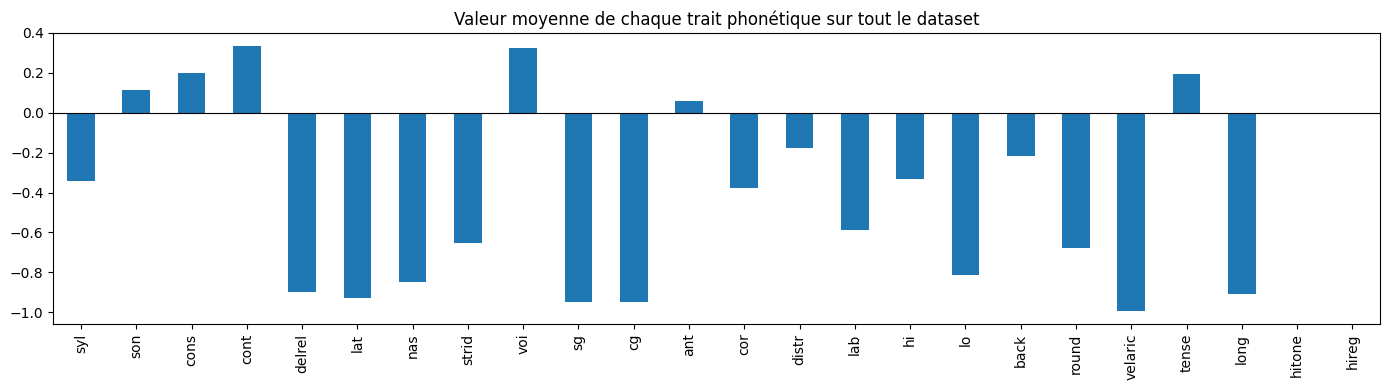

In [16]:
plt.figure(figsize=(14, 4))
feat_df.mean().plot(kind='bar')
plt.title("Valeur moyenne de chaque trait phonétique sur tout le dataset")
plt.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

## 5. Représentation visuelle des lettres

In [17]:
from PIL import Image, ImageDraw, ImageFont

font = ImageFont.truetype("fonts/NotoSans-Regular.ttf", size=48)

def char_to_image(char, size=64):
    img = Image.new("L", (size, size), color=255)  # fond blanc, mode grayscale
    draw = ImageDraw.Draw(img)
    
    # Centrer le glyphe sur la bounding box
    bbox = draw.textbbox((0, 0), char, font=font)
    w, h = bbox[2] - bbox[0], bbox[3] - bbox[1]
    x = (size - w) / 2 - bbox[0]
    y = (size - h) / 2 - bbox[1]
    
    draw.text((x, y), char, fill=0, font=font)  # texte noir
    return img


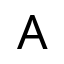

In [18]:
# Test 
char_to_image("A")

In [19]:
def image_to_array(char):
    img = char_to_image(char)
    arr = np.array(img, dtype=np.float32) / 255.0  # normalisation [0, 1]
    return arr

tqdm.pandas()
df['image'] = df['grapheme'].progress_apply(image_to_array)

print(f"Shape d'une image : {df['image'].iloc[0].shape}")
print(f"Min / Max : {df['image'].iloc[0].min():.2f} / {df['image'].iloc[0].max():.2f}")

100%|██████████| 18307/18307 [00:28<00:00, 649.77it/s] 

Shape d'une image : (64, 64)
Min / Max : 0.00 / 1.00


In [23]:
from ipywidgets import interact, IntSlider
import ipywidgets as widgets
from IPython.display import display, clear_output

scripts = df['script'].unique()
n_scripts = len(scripts)
n_cols = 8

def show_script(idx):
    script = scripts[idx]
    subset = df[df['script'] == script].head(n_cols)
    
    fig, axes = plt.subplots(1, len(subset), figsize=(n_cols * 1.5, 2))
    fig.suptitle(f"[{idx+1}/{n_scripts}] script : {script}", fontsize=12, fontweight='bold')
    
    for ax, (_, row) in zip(axes, subset.iterrows()):
        ax.imshow(row['image'], cmap='gray', vmin=0, vmax=1)
        ax.set_title(row['IPA'], fontsize=8)
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()

interact(show_script, idx=IntSlider(min=0, max=n_scripts-1, step=1, description='script'))

interactive(children=(IntSlider(value=0, description='script', max=190), Output()), _dom_classes=('widget-inte…

<function __main__.show_script(idx)>

In [24]:
noto_fonts = {
    "Arabic":               ("fonts/NotoSans-Arabic.ttf",               "https://github.com/googlefonts/noto-fonts/raw/main/hinted/ttf/NotoSansArabic/NotoSansArabic-Regular.ttf"),
    "Armenian":             ("fonts/NotoSans-Armenian.ttf",             "https://github.com/googlefonts/noto-fonts/raw/main/hinted/ttf/NotoSansArmenian/NotoSansArmenian-Regular.ttf"),
    "Bengali":              ("fonts/NotoSans-Bengali.ttf",              "https://github.com/googlefonts/noto-fonts/raw/main/hinted/ttf/NotoSansBengali/NotoSansBengali-Regular.ttf"),
    "Cherokee":             ("fonts/NotoSans-Cherokee.ttf",             "https://github.com/googlefonts/noto-fonts/raw/main/hinted/ttf/NotoSansCherokee/NotoSansCherokee-Regular.ttf"),
    "Devanagari":           ("fonts/NotoSans-Devanagari.ttf",           "https://github.com/googlefonts/noto-fonts/raw/main/hinted/ttf/NotoSansDevanagari/NotoSansDevanagari-Regular.ttf"),
    "Ethiopic":             ("fonts/NotoSans-Ethiopic.ttf",             "https://github.com/googlefonts/noto-fonts/raw/main/hinted/ttf/NotoSansEthiopic/NotoSansEthiopic-Regular.ttf"),
    "Georgian":             ("fonts/NotoSans-Georgian.ttf",             "https://github.com/googlefonts/noto-fonts/raw/main/hinted/ttf/NotoSansGeorgian/NotoSansGeorgian-Regular.ttf"),
    "Gujarati":             ("fonts/NotoSans-Gujarati.ttf",             "https://github.com/googlefonts/noto-fonts/raw/main/hinted/ttf/NotoSansGujarati/NotoSansGujarati-Regular.ttf"),
    "Gurmukhi":             ("fonts/NotoSans-Gurmukhi.ttf",             "https://github.com/googlefonts/noto-fonts/raw/main/hinted/ttf/NotoSansGurmukhi/NotoSansGurmukhi-Regular.ttf"),
    "Hangul":               ("fonts/NotoSans-Hangul.otf",               "https://raw.githubusercontent.com/googlefonts/noto-cjk/main/Sans/OTF/Korean/NotoSansCJKkr-Regular.otf"),
    "Hebrew":               ("fonts/NotoSans-Hebrew.ttf",               "https://github.com/googlefonts/noto-fonts/raw/main/hinted/ttf/NotoSansHebrew/NotoSansHebrew-Regular.ttf"),
    "HiraganaKatakana":     ("fonts/NotoSans-HiraganaKatakana.otf",     "https://raw.githubusercontent.com/googlefonts/noto-cjk/main/Sans/OTF/Japanese/NotoSansCJKjp-Regular.otf"),
    "Kannada":              ("fonts/NotoSans-Kannada.ttf",              "https://github.com/googlefonts/noto-fonts/raw/main/hinted/ttf/NotoSansKannada/NotoSansKannada-Regular.ttf"),
    "Khmer":                ("fonts/NotoSans-Khmer.ttf",                "https://github.com/googlefonts/noto-fonts/raw/main/hinted/ttf/NotoSansKhmer/NotoSansKhmer-Regular.ttf"),
    "Malayalam":            ("fonts/NotoSans-Malayalam.ttf",            "https://github.com/googlefonts/noto-fonts/raw/main/hinted/ttf/NotoSansMalayalam/NotoSansMalayalam-Regular.ttf"),
    "Mongolian":            ("fonts/NotoSans-Mongolian.ttf",            "https://github.com/googlefonts/noto-fonts/raw/main/hinted/ttf/NotoSansMongolian/NotoSansMongolian-Regular.ttf"),
    "Sinhala":              ("fonts/NotoSans-Sinhala.ttf",              "https://github.com/googlefonts/noto-fonts/raw/main/hinted/ttf/NotoSansSinhala/NotoSansSinhala-Regular.ttf"),
    "Syriac":               ("fonts/NotoSans-Syriac.ttf",               "https://github.com/googlefonts/noto-fonts/raw/main/hinted/ttf/NotoSansSyriac/NotoSansSyriac-Regular.ttf"),
    "Tamil":                ("fonts/NotoSans-Tamil.ttf",                "https://github.com/googlefonts/noto-fonts/raw/main/hinted/ttf/NotoSansTamil/NotoSansTamil-Regular.ttf"),
    "Telugu":               ("fonts/NotoSans-Telugu.ttf",               "https://github.com/googlefonts/noto-fonts/raw/main/hinted/ttf/NotoSansTelugu/NotoSansTelugu-Regular.ttf"),
    "Tibetan":              ("fonts/NotoSans-Tibetan.ttf",              "https://github.com/googlefonts/noto-fonts/raw/main/hinted/ttf/NotoSerifTibetan/NotoSerifTibetan-Regular.ttf"),
    "Thaana":               ("fonts/NotoSans-Thaana.ttf",               "https://github.com/googlefonts/noto-fonts/raw/main/hinted/ttf/NotoSansThaana/NotoSansThaana-Regular.ttf"),
    "Vai":                  ("fonts/NotoSans-Vai.ttf",                  "https://github.com/googlefonts/noto-fonts/raw/main/hinted/ttf/NotoSansVai/NotoSansVai-Regular.ttf"),
    "NKo":                  ("fonts/NotoSans-NKo.ttf",                  "https://github.com/googlefonts/noto-fonts/raw/main/hinted/ttf/NotoSansNKo/NotoSansNKo-Regular.ttf"),
    "Hanunoo":              ("fonts/NotoSans-Hanunoo.ttf",              "https://github.com/googlefonts/noto-fonts/raw/main/hinted/ttf/NotoSansHanifiRohingya/NotoSansHanifiRohingya-Regular.ttf"),
}

for name, (path, url) in noto_fonts.items():
    if not os.path.exists(path):
        r = requests.get(url)
        if r.status_code == 200:
            with open(path, "wb") as f:
                f.write(r.content)
            print(f"✅ {name}")
        else:
            print(f"❌ {name} — HTTP {r.status_code} — URL à vérifier")
    else:
        print(f"⏭️  {name} déjà présente")

⏭️  Arabic déjà présente
⏭️  Armenian déjà présente
⏭️  Bengali déjà présente
⏭️  Cherokee déjà présente
⏭️  Devanagari déjà présente
⏭️  Ethiopic déjà présente
⏭️  Georgian déjà présente
⏭️  Gujarati déjà présente
⏭️  Gurmukhi déjà présente
⏭️  Hangul déjà présente
⏭️  Hebrew déjà présente
⏭️  HiraganaKatakana déjà présente
⏭️  Kannada déjà présente
⏭️  Khmer déjà présente
⏭️  Malayalam déjà présente
⏭️  Mongolian déjà présente
⏭️  Sinhala déjà présente
⏭️  Syriac déjà présente
⏭️  Tamil déjà présente
⏭️  Telugu déjà présente
⏭️  Tibetan déjà présente
⏭️  Thaana déjà présente
⏭️  Vai déjà présente
⏭️  NKo déjà présente
⏭️  Hanunoo déjà présente


In [25]:
# Mapping entre les noms de scripts du WWSD et la police à utiliser
script_to_font = {
    # Latin de base
    "default": "fonts/NotoSans-Regular.ttf",

    # Scripts spécifiques
    "Acehnese":             "fonts/NotoSans-Regular.ttf",       # Latin étendu
    "Ainu (Katakana)":      "fonts/NotoSans-HiraganaKatakana.otf",
    "Amharic":              "fonts/NotoSans-Ethiopic.ttf",
    "Arabic":               "fonts/NotoSans-Arabic.ttf",
    "Armenian":             "fonts/NotoSans-Armenian.ttf",
    "Bambara":              "fonts/NotoSans-Regular.ttf",       # Latin
    "Bengali":              "fonts/NotoSans-Bengali.ttf",
    "Cherokee":             "fonts/NotoSans-Cherokee.ttf",
    "Comorian":             "fonts/NotoSans-Regular.ttf",       # Latin
    "Dari":                 "fonts/NotoSans-Arabic.ttf",
    "Dhivehi (Thaana)":     "fonts/NotoSans-Thaana.ttf",
    "Georgian (Mkhedruli)": "fonts/NotoSans-Georgian.ttf",
    "Hangul (Korean)":      "fonts/NotoSans-Hangul.otf",
    "Hanuno'o":             "fonts/NotoSans-Hanunoo.ttf",
    "Hebrew":               "fonts/NotoSans-Hebrew.ttf",
    "Hindi (Devanāgarī)":   "fonts/NotoSans-Devanagari.ttf",
    "Inuktitut":            "fonts/NotoSans-Regular.ttf",       # Latin/Syllabics → à vérifier
    "Japanese (Hiragana)":  "fonts/NotoSans-HiraganaKatakana.otf",
    "Japanese (Katakana)":  "fonts/NotoSans-HiraganaKatakana.otf",
    "Kannada":              "fonts/NotoSans-Kannada.ttf",
    "Khmer":                "fonts/NotoSans-Khmer.ttf",
    "Kurdish":              "fonts/NotoSans-Arabic.ttf",
    "Malayalam":            "fonts/NotoSans-Malayalam.ttf",
    "Mongolian":            "fonts/NotoSans-Mongolian.ttf",
    "N'Ko":                 "fonts/NotoSans-NKo.ttf",
    "Panjabi (Gurmukhi)":   "fonts/NotoSans-Gurmukhi.ttf",
    "Pashto":               "fonts/NotoSans-Arabic.ttf",
    "Persian (Braille)":    "fonts/NotoSans-Regular.ttf",       # Braille → à vérifier
    "Persian 1":            "fonts/NotoSans-Arabic.ttf",
    "Persian 2":            "fonts/NotoSans-Arabic.ttf",
    "Sinhala":              "fonts/NotoSans-Sinhala.ttf",
    "Somali (Abjad)":       "fonts/NotoSans-Arabic.ttf",
    "Sorani":               "fonts/NotoSans-Arabic.ttf",
    "Syriac":               "fonts/NotoSans-Syriac.ttf",
    "Tamil":                "fonts/NotoSans-Tamil.ttf",
    "Telugu":               "fonts/NotoSans-Telugu.ttf",
    "Tibetan":              "fonts/NotoSans-Tibetan.ttf",
    "Tigre (Abjad)":        "fonts/NotoSans-Ethiopic.ttf",
    "Tigre (Geez)":         "fonts/NotoSans-Ethiopic.ttf",
    "Tigrinya":             "fonts/NotoSans-Ethiopic.ttf",
    "Urdu":                 "fonts/NotoSans-Arabic.ttf",
    "Vai":                  "fonts/NotoSans-Vai.ttf",
    "Yiddish":              "fonts/NotoSans-Hebrew.ttf",
}

In [26]:
font_cache = {}

def get_font(script, size=48):
    # 1. Récupère le chemin configuré ou celui par défaut
    path = script_to_font.get(script, script_to_font.get("default"))
    key = (path, size)
    
    if key not in font_cache:
        try:
            # Tentative normale de chargement
            font_cache[key] = ImageFont.truetype(path, size=size)
        except OSError:
            print(f"⚠️ Impossible de charger la police pour '{script}' ({path}). Essai avec la police 'default'...")
            try:
                # Si ça échoue, on tente de forcer la police par défaut de ton dictionnaire
                default_path = script_to_font.get("default")
                font_cache[key] = ImageFont.truetype(default_path, size=size)
            except OSError:
                print(f"❌ La police par défaut a aussi échoué. Utilisation de ImageFont.load_default().")
                # Secours ultime (fourni par Pillow, ne plantera jamais)
                font_cache[key] = ImageFont.load_default()
                
    return font_cache[key]

def char_to_image(char, script, size=64):
    # Utilise bien la taille passée en paramètre (size) au lieu d'une valeur codée en dur
    font = get_font(script, size=int(size * 0.75)) 
    img = Image.new("L", (size, size), color=255)
    draw = ImageDraw.Draw(img)
    
    # Sécurité supplémentaire au cas où le graphème est vide ou NaN
    if not isinstance(char, str) or char == "":
        return img # Retourne une image blanche vide
        
    bbox = draw.textbbox((0, 0), char, font=font)
    w, h = bbox[2] - bbox[0], bbox[3] - bbox[1]
    x = (size - w) / 2 - bbox[0]
    y = (size - h) / 2 - bbox[1]
    draw.text((x, y), char, fill=0, font=font)
    return img

# Régénérer toutes les images avec la bonne police
df['image'] = df.progress_apply(lambda row: np.array(
    char_to_image(row['grapheme'], row['script'], size=64), dtype=np.float32) / 255.0, axis=1)

print("✅ Images régénérées avec les polices correctes (ou polices de secours)")

  0%|          | 1/18307 [00:00<34:34,  8.82it/s]

100%|██████████| 18307/18307 [00:27<00:00, 675.19it/s] 

✅ Images régénérées avec les polices correctes (ou polices de secours)


In [27]:
from ipywidgets import interact, IntSlider
import ipywidgets as widgets
from IPython.display import display, clear_output

scripts = df['script'].unique()
n_scripts = len(scripts)
n_cols = 8

def show_script(idx):
    script = scripts[idx]
    subset = df[df['script'] == script].head(n_cols)
    
    fig, axes = plt.subplots(1, len(subset), figsize=(n_cols * 1.5, 2))
    fig.suptitle(f"[{idx+1}/{n_scripts}] script : {script}", fontsize=12, fontweight='bold')
    
    for ax, (_, row) in zip(axes, subset.iterrows()):
        ax.imshow(row['image'], cmap='gray', vmin=0, vmax=1)
        ax.set_title(row['IPA'], fontsize=8)
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()

interact(show_script, idx=IntSlider(min=0, max=n_scripts-1, step=1, description='script'))

interactive(children=(IntSlider(value=0, description='script', max=190), Output()), _dom_classes=('widget-inte…

<function __main__.show_script(idx)>

In [28]:
problematic = [
    "Acehnese", "Ainu (Katakana)", "Bambara", "Comorian", "Dari",
    "Hangul (Korean)", "Hanuno'o", "Hebrew", "Inuktitut",
    "Japanese (Hiragana)", "Japanese (Katakana)",
    "Persian (Braille)", "Tigre (Abjad)"
]

for script in problematic:
    path = script_to_font.get(script, "NON TROUVÉ dans script_to_font")
    exists = os.path.exists(path) if path != "NON TROUVÉ dans script_to_font" else False
    print(f"{'✅' if exists else '❌'} {script:30s} → {path}")

✅ Acehnese                       → fonts/NotoSans-Regular.ttf
✅ Ainu (Katakana)                → fonts/NotoSans-HiraganaKatakana.otf
✅ Bambara                        → fonts/NotoSans-Regular.ttf
✅ Comorian                       → fonts/NotoSans-Regular.ttf
✅ Dari                           → fonts/NotoSans-Arabic.ttf
✅ Hangul (Korean)                → fonts/NotoSans-Hangul.otf
✅ Hanuno'o                       → fonts/NotoSans-Hanunoo.ttf
✅ Hebrew                         → fonts/NotoSans-Hebrew.ttf
✅ Inuktitut                      → fonts/NotoSans-Regular.ttf
✅ Japanese (Hiragana)            → fonts/NotoSans-HiraganaKatakana.otf
✅ Japanese (Katakana)            → fonts/NotoSans-HiraganaKatakana.otf
✅ Persian (Braille)              → fonts/NotoSans-Regular.ttf
✅ Tigre (Abjad)                  → fonts/NotoSans-Ethiopic.ttf


In [29]:
# 1. Supprimer les scripts sans police adéquate
scripts_to_drop = [
    "Acehnese", "Bambara", "Comorian", "Hanuno'o",
    "Inuktitut", "Persian (Braille)", "Tigre (Abjad)"
]

before = len(df)
df = df[~df['script'].isin(scripts_to_drop)]
print(f"Lignes supprimées (scripts sans police) : {before - len(df)}")

# 2. Supprimer les lignes avec images entièrement blanches (Hebrew et N'Ko partiels)
def is_blank(img_array):
    return img_array.min() == 1.0  # normalisé [0,1], blanc = 1.0

before = len(df)
df = df[~df['image'].apply(is_blank)]
print(f"Lignes supprimées (glyphes blancs)      : {before - len(df)}")

print(f"\nDataFrame final : {len(df)} lignes")
print(f"Scripts restants : {df['script'].nunique()}")
print(df['script'].value_counts().to_string())

Lignes supprimées (scripts sans police) : 653
Lignes supprimées (glyphes blancs)      : 0

DataFrame final : 17654 lignes
Scripts restants : 184
script
Cherokee                1574
Bengali                  329
English (BrE)            300
Amharic                  250
Pashto                   243
Tigrinya                 209
Vai                      206
Tigre (Geez)             202
Mongolian                195
Urdu                     186
Sorani                   182
Kurdish                  175
Archi                    164
Faroese                  164
Persian 2                157
German                   154
Zulu 2                   154
Dari                     153
Swedish                  153
Abaza                    146
Persian 1                137
Adyghe                   136
Arabic                   136
Russian                  136
Nanai                    135
Danish                   133
Dutch                    133
Icelandic                132
Sinhala                  132
Kabardi

## 6. Modélisation

In [35]:
pip install scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 5.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.6/31.6 MB 4.2 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 kB 2.9 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip available: 22.3 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [37]:
from sklearn.model_selection import train_test_split

# Préparer X et y
X = np.stack(df['features'].values)           # (N, 24) traits phonétiques
y = np.stack(df['image'].values)              # (N, 64, 64) images

scripts = df['script'].values

# Split stratifié : 70% train, 15% val, 15% test
X_train, X_temp, y_train, y_temp, s_train, s_temp = train_test_split(
    X, y, scripts, test_size=0.30, stratify=scripts, random_state=42
)
X_val, X_test, y_val, y_test, s_val, s_test = train_test_split(
    X_temp, y_temp, s_temp, test_size=0.50, stratify=s_temp, random_state=42
)

print(f"Train : {len(X_train)} ({100*len(X_train)/len(X):.1f}%)")
print(f"Val   : {len(X_val)}   ({100*len(X_val)/len(X):.1f}%)")
print(f"Test  : {len(X_test)}  ({100*len(X_test)/len(X):.1f}%)")

Train : 12357 (70.0%)
Val   : 2648   (15.0%)
Test  : 2649  (15.0%)


Baseline Ridge — MSE val : 0.0596


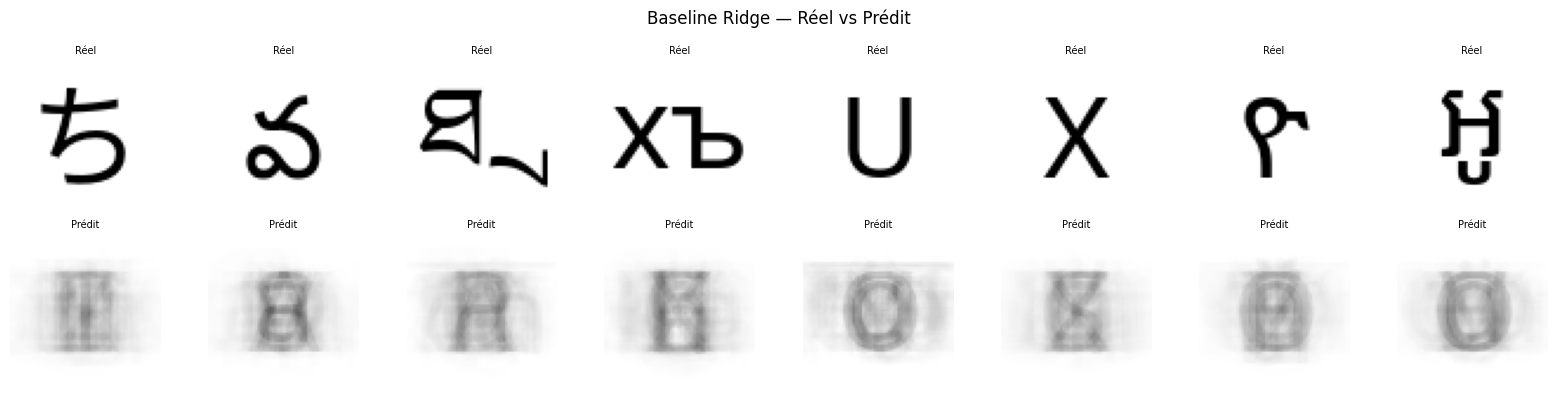

In [38]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

# Aplatir les images en vecteurs (N, 64*64)
y_train_flat = y_train.reshape(len(y_train), -1)
y_val_flat   = y_val.reshape(len(y_val), -1)

# Entraînement
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train_flat)

# Évaluation
y_pred_flat = ridge.predict(X_val)
mse = mean_squared_error(y_val_flat, y_pred_flat)
print(f"Baseline Ridge — MSE val : {mse:.4f}")

# Visualisation de quelques reconstructions
y_pred_imgs = y_pred_flat.reshape(-1, 64, 64)
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(8):
    axes[0, i].imshow(y_val[i], cmap='gray', vmin=0, vmax=1)
    axes[0, i].set_title("Réel", fontsize=7)
    axes[0, i].axis('off')
    axes[1, i].imshow(y_pred_imgs[i], cmap='gray', vmin=0, vmax=1)
    axes[1, i].set_title("Prédit", fontsize=7)
    axes[1, i].axis('off')
plt.suptitle("Baseline Ridge — Réel vs Prédit")
plt.tight_layout()
plt.show()

In [39]:
pip install torch


[notice] A new release of pip available: 22.3 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [40]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Dataset
def to_tensor(X, y):
    return TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.float32).unsqueeze(1)  # (N, 1, 64, 64)
    )

train_ds = to_tensor(X_train, y_train)
val_ds   = to_tensor(X_val,   y_val)
test_ds  = to_tensor(X_test,  y_test)

train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)
val_dl   = DataLoader(val_ds,   batch_size=64)

In [41]:
# Architecture du décodeur CNN
class PhoneticDecoder(nn.Module):
    def __init__(self, input_dim=24):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 4 * 4 * 64),  # seed pour le décodeur conv
            nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            # (64, 4, 4) → (32, 8, 8)
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            # (32, 8, 8) → (16, 16, 16)
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            # (16, 16, 16) → (8, 32, 32)
            nn.ConvTranspose2d(16, 8,  kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            # (8, 32, 32) → (1, 64, 64)
            nn.ConvTranspose2d(8,  1,  kernel_size=4, stride=2, padding=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        x = self.fc(x)
        x = x.view(-1, 64, 4, 4)
        return self.decoder(x)

model = PhoneticDecoder(input_dim=X_train.shape[1])
print(model)
print(f"\nNombre de paramètres : {sum(p.numel() for p in model.parameters()):,}")

PhoneticDecoder(
  (fc): Sequential(
    (0): Linear(in_features=24, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=512, bias=True)
    (5): ReLU()
    (6): Linear(in_features=512, out_features=1024, bias=True)
    (7): ReLU()
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(32, 16, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(16, 8, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): ConvTranspose2d(8, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): Sigmoid()
  )
)

Nombre de paramètres : 736,313


Epoch  10/50 — Train: 0.0548 — Val: 0.0556
Epoch  20/50 — Train: 0.0513 — Val: 0.0537
Epoch  30/50 — Train: 0.0494 — Val: 0.0530
Epoch  40/50 — Train: 0.0484 — Val: 0.0530
Epoch  50/50 — Train: 0.0476 — Val: 0.0530


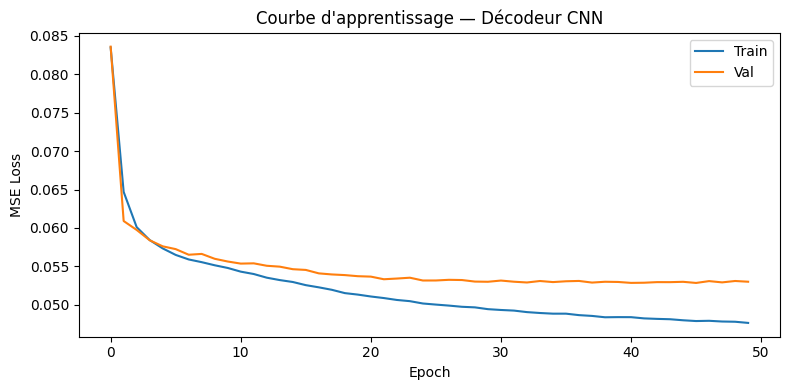

In [44]:
# Entraînement
device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model     = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

N_EPOCHS = 50
train_losses, val_losses = [], []

for epoch in range(N_EPOCHS):
    # Train
    model.train()
    batch_losses = []
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    train_losses.append(np.mean(batch_losses))

    # Validation
    model.eval()
    with torch.no_grad():
        val_loss = np.mean([
            criterion(model(xb.to(device)), yb.to(device)).item()
            for xb, yb in val_dl
        ])
    val_losses.append(val_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{N_EPOCHS} — Train: {train_losses[-1]:.4f} — Val: {val_losses[-1]:.4f}")

# Courbe de loss
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Train")
plt.plot(val_losses,   label="Val")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Courbe d'apprentissage — Décodeur CNN")
plt.legend()
plt.tight_layout()
plt.show()

In [47]:
import numpy as np

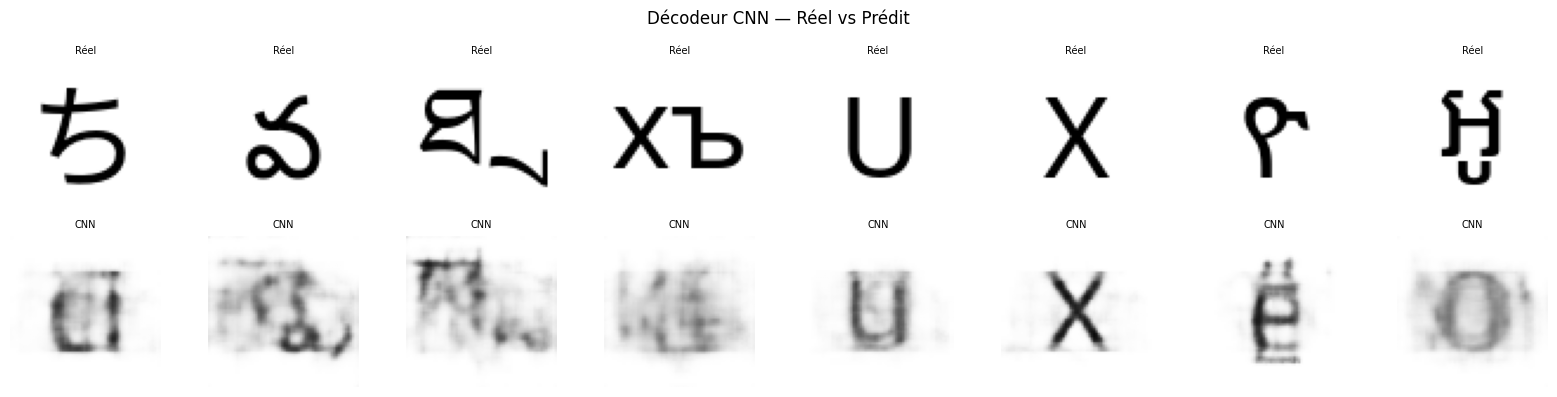

In [49]:
# Visualisation des reconstructions CNN
model.eval()
with torch.no_grad():
    X_sample = torch.tensor(X_val[:8], dtype=torch.float32).to(device)
    y_pred_tensor = model(X_sample).cpu().squeeze(1)
    y_pred_cnn = np.array(y_pred_tensor.tolist(), dtype=np.float32)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(8):
    axes[0, i].imshow(y_val[i],       cmap='gray', vmin=0, vmax=1)
    axes[0, i].set_title("Réel",      fontsize=7)
    axes[0, i].axis('off')
    axes[1, i].imshow(y_pred_cnn[i],  cmap='gray', vmin=0, vmax=1)
    axes[1, i].set_title("CNN",       fontsize=7)
    axes[1, i].axis('off')
plt.suptitle("Décodeur CNN — Réel vs Prédit")
plt.tight_layout()
plt.show()